Data Cleaning

Dataset Shape: (45593, 20)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         4559

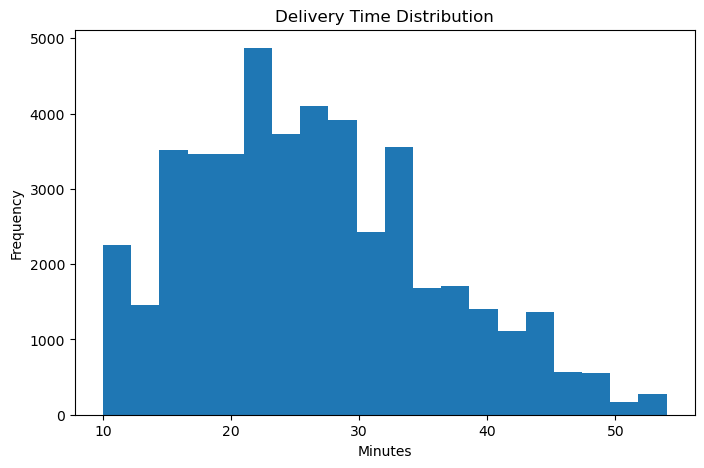

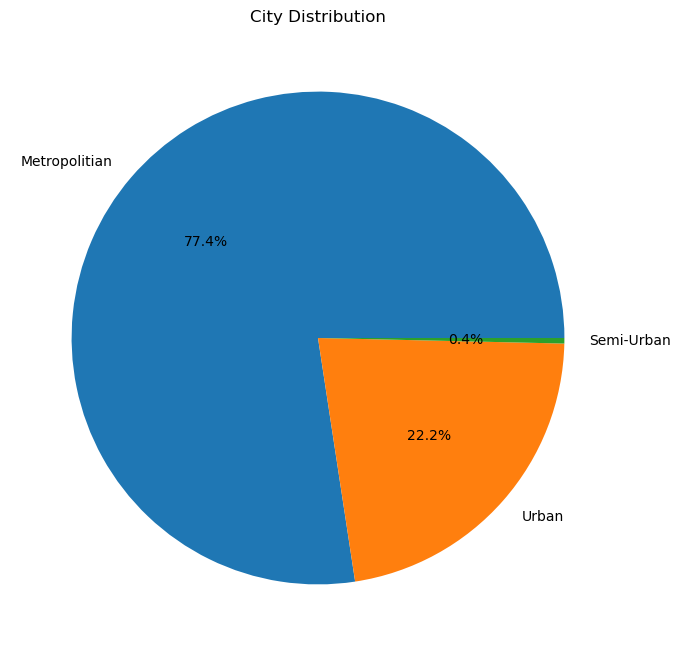

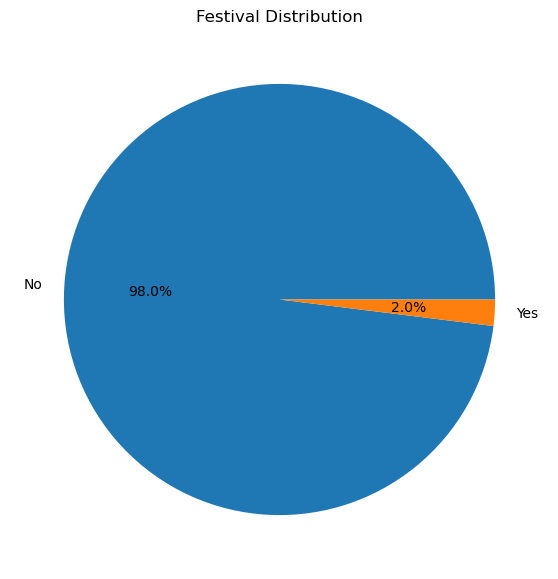

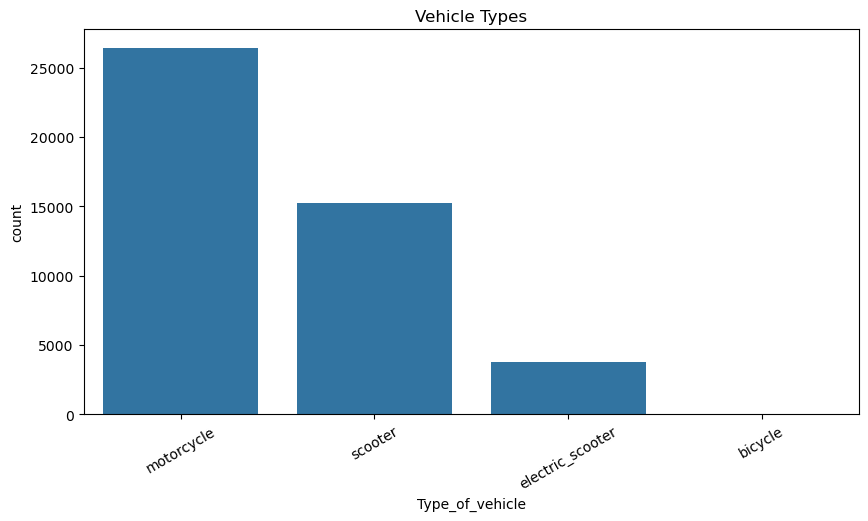

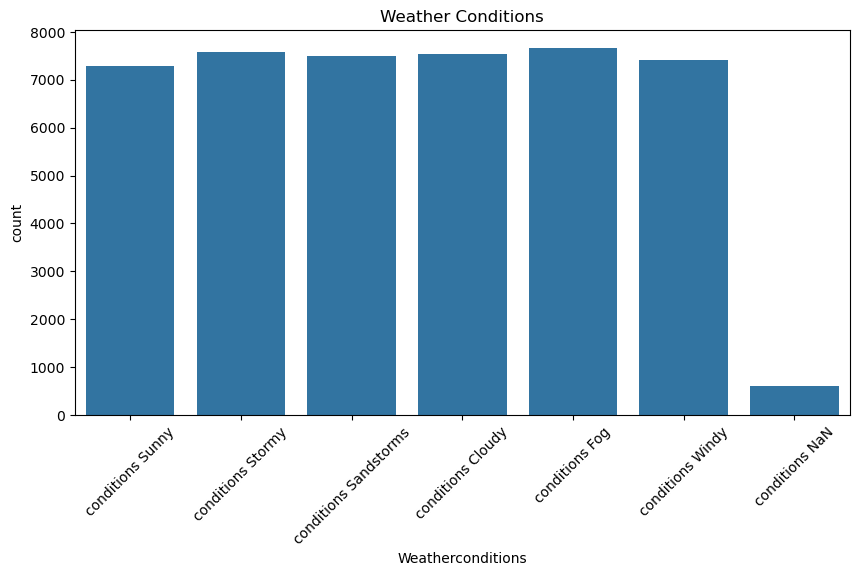

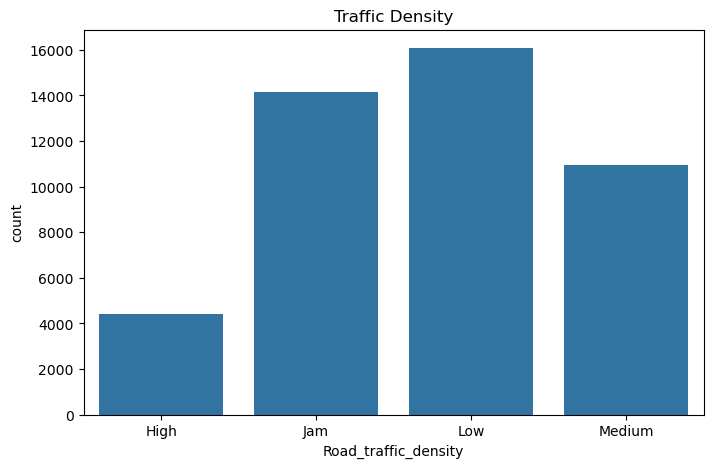

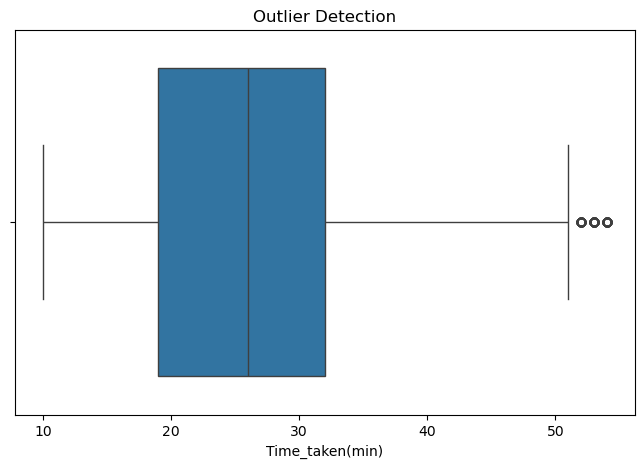

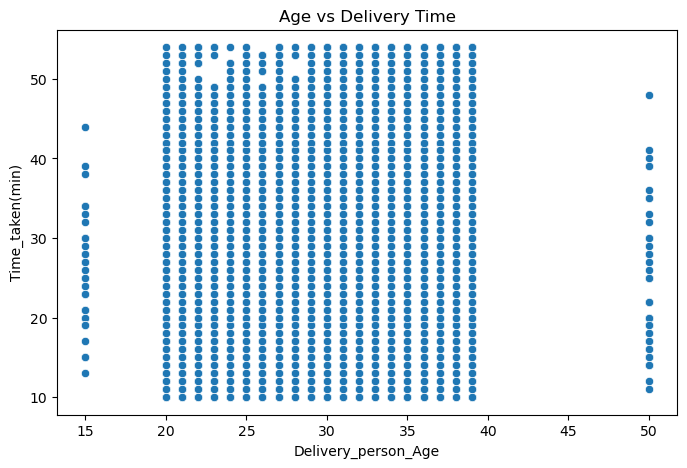

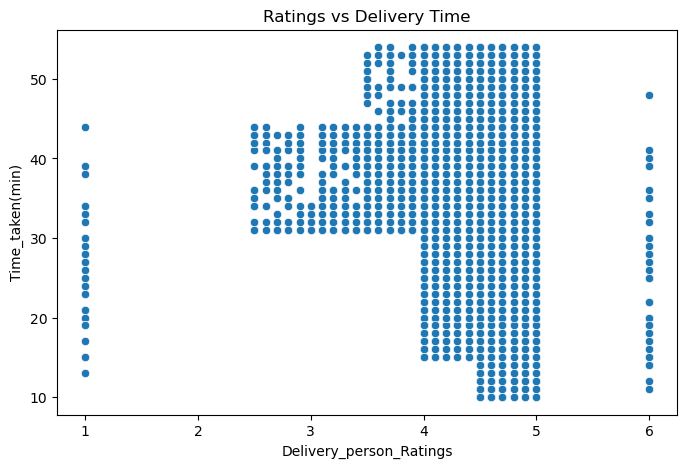

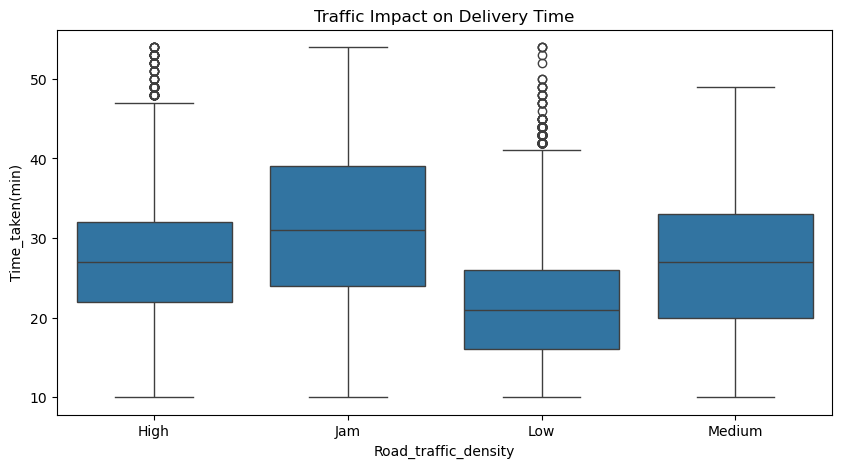

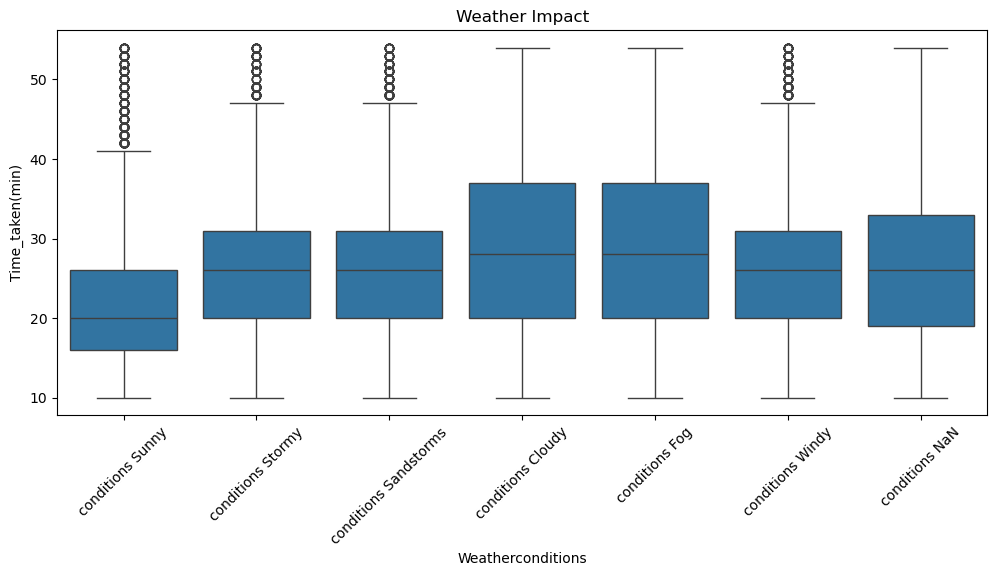

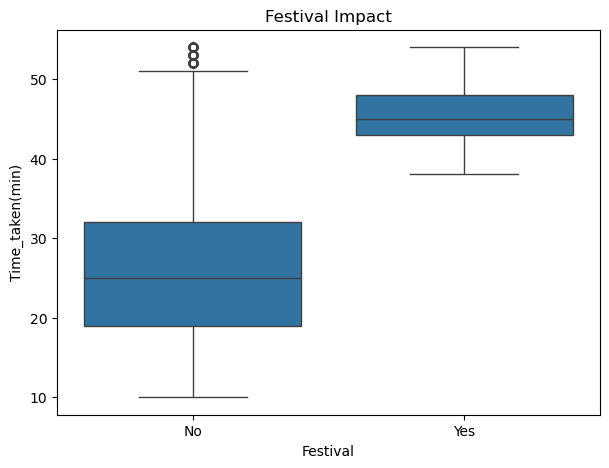

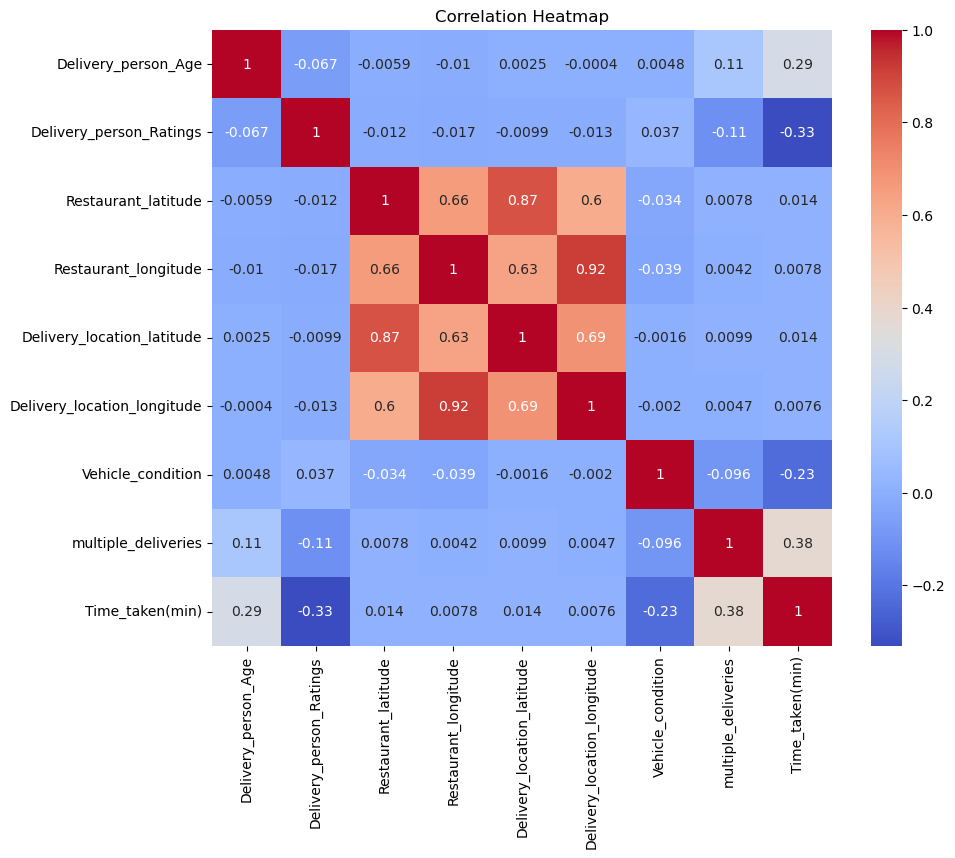

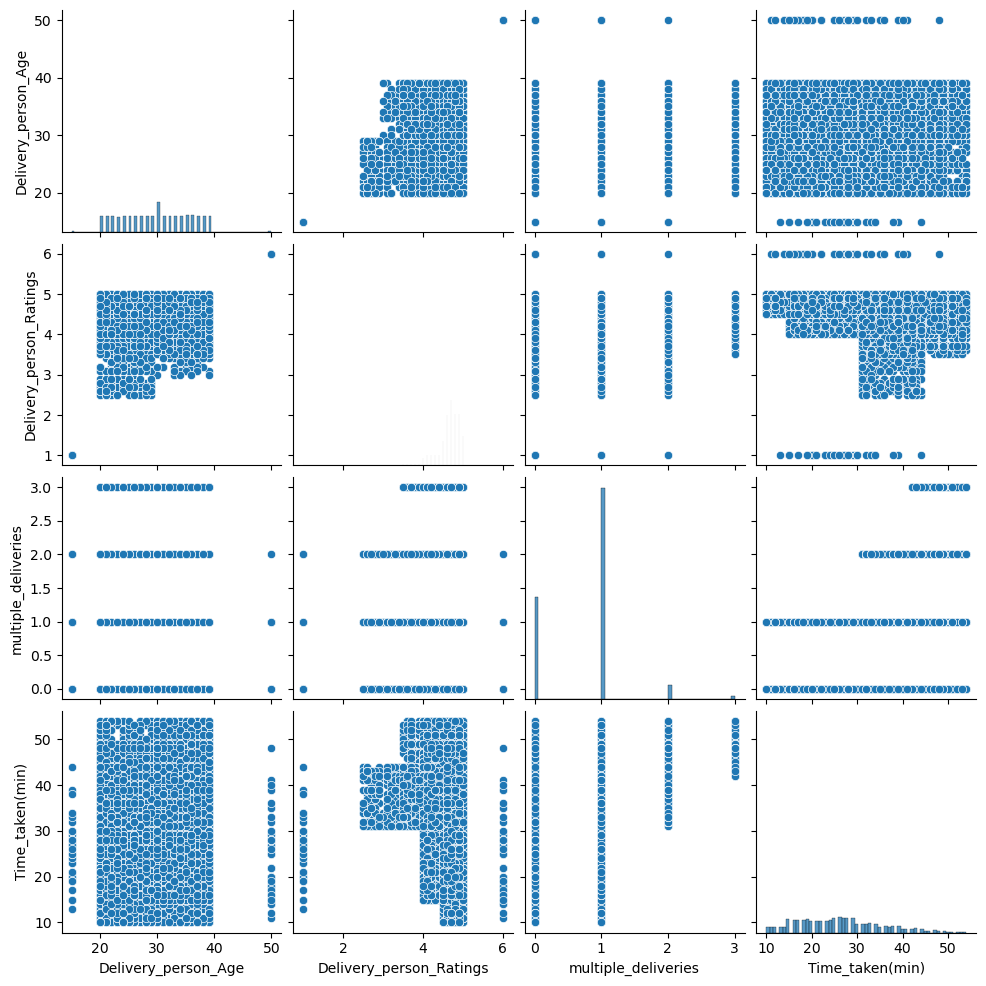


PROJECT CONCLUSION

1. Traffic density strongly affects delivery time.
2. Festival days increase delays.
3. Bad weather increases delivery duration.
4. Multiple deliveries increase delivery time.
5. Most delivery partners have ratings above 4.
6. Motorcycles are the most used vehicles.
7. Dataset is cleaned and ready for Machine Learning.

Recommended Models:
- Linear Regression
- Random Forest
- XGBoost
- Decision Tree



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)

# ==========================
# DATA CLEANING
# ==========================

# Replace string NaN values
df = df.replace("NaN ", np.nan)

# Convert numerical columns

numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill numerical missing values

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values

categorical_cols = [
    "Weatherconditions",
    "Road_traffic_density",
    "Festival",
    "City"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates

df = df.drop_duplicates()

# Extract target column

df["Time_taken(min)"] = (
    df["Time_taken(min)"]
    .astype(str)
    .str.extract("(\d+)")[0]
    .astype(float)
)

# ==========================
# BASIC INFORMATION
# ==========================

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDescriptive Statistics")
print(df.describe())

# ==========================
# MEAN MEDIAN STD
# ==========================

print("\nMean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

# ==========================
# HISTOGRAM
# ==========================

plt.figure(figsize=(8,5))
plt.hist(df["Time_taken(min)"], bins=20)
plt.title("Delivery Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

# ==========================
# PIE CHART CITY
# ==========================

city_counts = df["City"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%"
)
plt.title("City Distribution")
plt.show()

# ==========================
# PIE CHART FESTIVAL
# ==========================

festival_counts = df["Festival"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    festival_counts,
    labels=festival_counts.index,
    autopct="%1.1f%%"
)
plt.title("Festival Distribution")
plt.show()

# ==========================
# VEHICLE TYPES
# ==========================

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Type_of_vehicle"
)
plt.title("Vehicle Types")
plt.xticks(rotation=30)
plt.show()

# ==========================
# WEATHER CONDITIONS
# ==========================

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Weatherconditions"
)
plt.xticks(rotation=45)
plt.title("Weather Conditions")
plt.show()

# ==========================
# TRAFFIC DENSITY
# ==========================

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Road_traffic_density"
)
plt.title("Traffic Density")
plt.show()

# ==========================
# BOXPLOT
# ==========================

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["Time_taken(min)"]
)
plt.title("Outlier Detection")
plt.show()

# ==========================
# AGE VS TIME
# ==========================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken(min)"
)
plt.title("Age vs Delivery Time")
plt.show()

# ==========================
# RATINGS VS TIME
# ==========================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Delivery_person_Ratings",
    y="Time_taken(min)"
)
plt.title("Ratings vs Delivery Time")
plt.show()

# ==========================
# TRAFFIC IMPACT
# ==========================

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Road_traffic_density",
    y="Time_taken(min)"
)
plt.title("Traffic Impact on Delivery Time")
plt.show()

# ==========================
# WEATHER IMPACT
# ==========================

plt.figure(figsize=(12,5))
sns.boxplot(
    data=df,
    x="Weatherconditions",
    y="Time_taken(min)"
)
plt.xticks(rotation=45)
plt.title("Weather Impact")
plt.show()

# ==========================
# FESTIVAL IMPACT
# ==========================

plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Festival",
    y="Time_taken(min)"
)
plt.title("Festival Impact")
plt.show()

# ==========================
# CORRELATION HEATMAP
# ==========================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# ==========================
# PAIRPLOT
# ==========================

sns.pairplot(
    df[
        [
            "Delivery_person_Age",
            "Delivery_person_Ratings",
            "multiple_deliveries",
            "Time_taken(min)"
        ]
    ]
)
plt.show()

# ==========================
# FINAL CONCLUSION
# ==========================

print("""
PROJECT CONCLUSION

1. Traffic density strongly affects delivery time.
2. Festival days increase delays.
3. Bad weather increases delivery duration.
4. Multiple deliveries increase delivery time.
5. Most delivery partners have ratings above 4.
6. Motorcycles are the most used vehicles.
7. Dataset is cleaned and ready for Machine Learning.

Recommended Models:
- Linear Regression
- Random Forest
- XGBoost
- Decision Tree
""")
